In [1]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

In [2]:
# Inception Block Architecture

class Inception(nn.Module):
    def __init__(
        self,
        c1: int,
        c2: tuple[int, int],
        c3: tuple[int, int],
        c4: int,
    ) -> None:
        super().__init__()

        # feature extract: 1x1 Conv
        self.b1_1 = nn.LazyConv2d(
            out_channels=c1,
            kernel_size=1,
        )

        # channel reduction: 1x1 Conv
        # feature extract: 3x3 Conv
        self.b2_1 = nn.LazyConv2d(
            out_channels=c2[0],
            kernel_size=1,
        )
        self.b2_2 = nn.LazyConv2d(
            out_channels=c2[1],
            kernel_size=3,
            padding=1,
        )

        # channel reduction: 1x1 Conv
        # feature extract: 5x5 Conv
        self.b3_1 = nn.LazyConv2d(
            out_channels=c3[0],
            kernel_size=1,
        )
        self.b3_2 = nn.LazyConv2d(
            out_channels=c3[1],
            kernel_size=5,
            padding=2,
        )

        # feature extract: 3x3 Pooling
        # channel adjustment: 1x1 Conv
        self.b4_1 = nn.MaxPool2d(
            kernel_size=3,
            stride=1,
            padding=1,
        )
        self.b4_2 = nn.LazyConv2d(
            out_channels=c4,
            kernel_size=1,
        )


    def forward(
        self,
        X: torch.Tensor,
    ) -> torch.Tensor:
        branch1 = F.relu(
            self.b1_1(X)
        )

        branch2 = F.relu(
            self.b2_2(
                F.relu(
                    self.b2_1(X)
                )
            )
        )

        branch3 = F.relu(
            self.b3_2(
                F.relu(
                    self.b3_1(X)
                )
            )
        )

        branch4 = F.relu(
            self.b4_2(
                self.b4_1(X)
            )
        )

        return torch.cat(
            (
                branch1,
                branch2,
                branch3,
                branch4,
            ),
            dim=1,
        )

In [3]:
def googlenet_b1() -> nn.Sequential:
    return nn.Sequential(
        nn.LazyConv2d(
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
        ),
        nn.ReLU(),
        
        nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1,
        ),
    )
    
def googlenet_b2() -> nn.Sequential:
    return nn.Sequential(
        nn.LazyConv2d(
            out_channels=64,
            kernel_size=1,
        ),
        nn.ReLU(),

        nn.LazyConv2d(
            out_channels=192,
            kernel_size=3,
            padding=1,
        ),
        nn.ReLU(),

        nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1,
        ), 
    )
    
    
def googlenet_b3() -> nn.Sequential:
    return nn.Sequential(
        
        # 192 -> 256 channels
        Inception(
            c1=64,
            c2=(96, 128),
            c3=(16, 32),
            c4=32,
        ),
        
        # 256 -> 480 channels
        Inception(
            c1=128,
            c2=(128, 192),
            c3=(32, 96),
            c4=64,
        ),
        
        nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1,
        ),
    )
    

def googlenet_b4() -> nn.Sequential:
    return nn.Sequential(
        
        # 480 -> 512 channels
        Inception(
            c1=192,
            c2=(96, 208),
            c3=(16, 48),
            c4=64,
        ),
        
        # 512 -> 512 channels
        Inception(
            c1=160,
            c2=(112, 224),
            c3=(24, 64),
            c4=64,
        ),

        # 512 -> 512 channels
        Inception(
            c1=128,
            c2=(128, 256),
            c3=(24, 64),
            c4=64,
        ),

        # 512 -> 528 channels
        Inception(
            c1=112,
            c2=(144, 288),
            c3=(32, 64),
            c4=64,
        ),

        # 528 -> 832 channels
        Inception(
            c1=256,
            c2=(160, 320),
            c3=(32, 128),
            c4=128,
        ),
        
        # Input:  [B, 832, 6, 6]
        # Output: [B, 832, 3, 3]
        nn.MaxPool2d(
            kernel_size=3,
            stride=2,
            padding=1,
        ),
    )
    
    
def googlenet_b5() -> nn.Sequential:
    return nn.Sequential(
        # 832 -> 832 channels
        Inception(
            c1=256,
            c2=(160, 320),
            c3=(32, 128),
            c4=128,
        ),

        # 832 -> 1024 channels
        Inception(
            c1=384,
            c2=(192, 384),
            c3=(48, 128),
            c4=128,
        ),
        
        # Input:  [B, 1024, 3, 3]
        # Output: [B, 1024, 1, 1]
        nn.AdaptiveAvgPool2d(
            output_size=(1, 1),
        ),
        
        # Input:  [B, 1024, 1, 1]
        # Output: [B, 1024]
        nn.Flatten(),
    )
    

In [4]:
# GoogLeNet Architecture

class GoogleNet(d2l.Classifier):
    def __init__(
        self,
        lr: float = 1e-1,
        num_classes: int = 10,
    ) -> None:
        super().__init__()
        
        self.save_hyperparameters()

        self.net = nn.Sequential(
            googlenet_b1(),
            googlenet_b2(),
            googlenet_b3(),
            googlenet_b4(),
            googlenet_b5(),
            
            # Linear:
            # [B, 1024] -> [B, 10]
            nn.LazyLinear(
                out_features=num_classes,
            ),
        )
        

In [5]:
# GoogleNet Tensor Shape 추적

model = GoogleNet()

sample_input = torch.randn(
    1,
    1,
    96,
    96,
)

model.apply_init(
    [sample_input],
    d2l.init_cnn,
)

X: torch.Tensor = sample_input

with torch.no_grad():
    for layer in model.net:
        X = layer(X)

        print(
            f"{layer.__class__.__name__:<12}",
            "output shape:",
            tuple(X.shape),
        )

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(
    "Parameter count:",
    f"{parameter_count:,}",
)

Sequential   output shape: (1, 64, 24, 24)
Sequential   output shape: (1, 192, 12, 12)
Sequential   output shape: (1, 480, 6, 6)
Sequential   output shape: (1, 832, 3, 3)
Sequential   output shape: (1, 1024)
Linear       output shape: (1, 10)
Parameter count: 5,977,530


In [6]:
# Training Device Checking

cuda_available = torch.cuda.is_available()

num_gpus = int(
    cuda_available
)

training_device = torch.device(
    "cuda"
    if cuda_available
    else "cpu"
)

print(
    "Device:",
    training_device,
)

if cuda_available:
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti


In [7]:
# Fashion-MNIST & GoogleNet Training 준비

model = GoogleNet(
    lr=1e-2
)

trainer = d2l.Trainer(
    max_epochs=10,
    num_gpus=num_gpus,
)

data = d2l.FashionMNIST(
    batch_size=128,
    resize=(96, 96),
)

initialization_batch: torch.Tensor = next(
    iter(data.get_dataloader(True))
)[0]

model.apply_init(
    [initialization_batch],
    d2l.init_cnn,
)

with torch.no_grad():
    sample_logits: torch.Tensor = model(
        initialization_batch[:1]
    )

print(
    "Training batch:",
    tuple(initialization_batch.shape),
)
print(
    "Sample logits:",
    tuple(sample_logits.shape),
)

Training batch: (128, 1, 96, 96)
Sample logits: (1, 10)


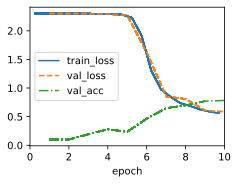

In [8]:
# GoogleNet Training

trainer.fit(
    model,
    data,
)